In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import norm
import statsmodels.formula.api as smf

In [6]:
#Q1c

# h0: mu = 1.8
# h1: mu /= 1.8

mu = 1.8
std = 0.5
n = 50
xbar = 1.6
alpha = 0.05

se = std / np.sqrt(n)
z_calc = (xbar - mu) / se
print(f"z_calc: {z_calc}")

z_neg = stats.norm.ppf(alpha/2)
z_pos = stats.norm.ppf(1 - alpha/2)
print(f"{z_neg} ------- {z_calc} ------ {z_pos}")

#reject null hypo , accept alternate hypo

z_calc: -2.8284271247461894
-1.9599639845400545 ------- -2.8284271247461894 ------ 1.959963984540054


In [13]:
#Q2a

# Set random seed for reproducibility
np.random.seed(123)

n_samples = 200

# Generate synthetic employee salary dataset
experience_years = np.random.randint(1, 20, n_samples)  # Years of experience

education_level = np.random.randint(1, 4, n_samples)
# 1: Bachelor's, 2: Master's, 3: PhD

job_position = np.random.randint(1, 6, n_samples)
# Job level (1-5)

# Salary (Target) with some noise
salary = (
    (experience_years * 1000)
    + (education_level * 8000)
    + (job_position * 3000)
    + np.random.randn(n_samples) * 10000
)

# Convert to DataFrame
df = pd.DataFrame({
    'Experience (Years)': experience_years,
    'Education Level': education_level,
    'Job Position': job_position,
    'Salary': salary
})

df.head()

,Experience (Years),Education Level,Job Position,Salary
0,14,2,4,28942.141337
1,3,3,2,24171.710123
2,3,1,4,19539.099661
3,7,3,3,41094.031564
4,18,2,4,38274.162676


<Axes: xlabel='Salary', ylabel='Experience (Years)'>

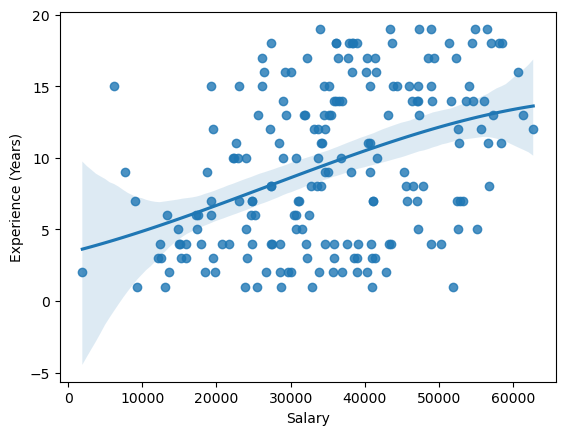

In [70]:
## Checking linearity

sns.regplot(x=df["Salary"], y=df["Experience (Years)"], order = 3)

### lm = smf.ols(
    'Q("Salary") ~ C(Q("Education Level")) + Q("Job Position_4") + Q("Job Position_5")',
    data=df1
).fit()

print(lm.summary())

In [58]:
df1 = pd.get_dummies(df, columns=["Job Position"])

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Experience (Years)  200 non-null    int32  
 1   Education Level     200 non-null    int32  
 2   Job Position        200 non-null    int32  
 3   Salary              200 non-null    float64
dtypes: float64(1), int32(3)
memory usage: 4.0 KB


In [78]:
lm = smf.ols(
    'Q("Salary") ~ C(Q("Education Level")) + C(Q("Job Position"))',
    data=df
).fit()

print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:            Q("Salary")   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     10.62
Date:                Wed, 06 May 2026   Prob (F-statistic):           3.47e-10
Time:                        20:31:03   Log-Likelihood:                -2147.6
No. Observations:                 200   AIC:                             4309.
Df Residuals:                     193   BIC:                             4332.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [71]:
df["Exp2"]  = df["Experience (Years)"].values ** 2

In [80]:
lm = smf.ols(
    'Q("Salary") ~ Q("Experience (Years)") + Exp2',
    data=df
).fit()

print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:            Q("Salary")   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     20.45
Date:                Wed, 06 May 2026   Prob (F-statistic):           8.48e-09
Time:                        21:00:40   Log-Likelihood:                -2157.3
No. Observations:                 200   AIC:                             4321.
Df Residuals:                     197   BIC:                             4331.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                2